# 🛍️ Customer Journey Analysis & Purchase Conversion Prediction

This notebook analyzes customer journey data to predict purchase conversion.

**Pipeline:**
1. Data Loading & Merging
2. Cleaning & Column Consolidation
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Preprocessing
6. Modeling — RF Balanced | SMOTE + GridSearch | SMOTEENN

**Author:** [ENG RAHMA SABER] &nbsp;&nbsp; **Date:** [2/15/2026]

## 1. Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score
)

# Imbalance Handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.pipeline import Pipeline as ImbPipeline

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 2. Data Loading & Merging

In [ ]:
print("--- Loading Datasets ---")

# Update paths as needed
products  = pd.read_csv(r'/content/products.csv')
geography = pd.read_csv(r'/content/geography.csv')
customers = pd.read_csv(r'/content/customers.csv')
reviews   = pd.read_csv(r'/content/customer_reviews.csv')
journey   = pd.read_csv(r'/content/customer_journey.csv')

print("Datasets loaded successfully.")

# Merge Geography into Customers
print("\nMerging Geography and Customers...")
customers = customers.merge(geography, on='GeographyID', how='left')

# Merge Reviews with Customers and Products
print("Merging Reviews data...")
reviews_full = (
    reviews
    .merge(customers, on='CustomerID', how='left')
    .merge(products,  on='ProductID',  how='left')
)

# Merge Journey with Customers and Products
print("Merging Journey data...")
journey_full = (
    journey
    .merge(customers, on='CustomerID', how='left')
    .merge(products,  on='ProductID',  how='left')
)

# Outer Join Journey and Reviews
print("Performing final outer merge...")
final_df = pd.merge(
    journey_full,
    reviews_full,
    on=['CustomerID', 'ProductID'],
    how='outer',
    suffixes=('_journey', '_review')
)

# Remove duplicate columns
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

# Save intermediate
final_df.to_csv('merged_all.csv', index=False)
print("Intermediate merge saved to merged_all.csv")
print(f'Shape: {final_df.shape}')
final_df.head()

--- Loading Datasets ---
Datasets loaded successfully.

Merging Geography and Customers...
Merging Reviews data...
Merging Journey data...
Performing final outer merge...
Intermediate merge saved to merged_all.csv
Shape: (4947, 31)


,JourneyID,CustomerID,ProductID,VisitDate,Stage,Action,Duration,CustomerName_journey,Email_journey,Gender_journey,...,CustomerName_review,Email_review,Gender_review,Age_review,GeographyID_review,Country_review,City_review,ProductName_review,Category_review,Price_review
0,577.0,1,1,2025-12-17,Homepage,Click,115.0,Emma Anderson,emma.anderson@example.com,Male,...,Emma Anderson,emma.anderson@example.com,Male,50.0,2.0,Germany,Berlin,Running Shoes,Sports,223.75
1,2040.0,1,1,2023-03-11,Homepage,Click,26.0,Emma Anderson,emma.anderson@example.com,Male,...,Emma Anderson,emma.anderson@example.com,Male,50.0,2.0,Germany,Berlin,Running Shoes,Sports,223.75
2,3077.0,1,1,2024-03-18,Homepage,View,66.0,Emma Anderson,emma.anderson@example.com,Male,...,Emma Anderson,emma.anderson@example.com,Male,50.0,2.0,Germany,Berlin,Running Shoes,Sports,223.75
3,3388.0,1,1,2024-06-28,Homepage,Click,18.0,Emma Anderson,emma.anderson@example.com,Male,...,Emma Anderson,emma.anderson@example.com,Male,50.0,2.0,Germany,Berlin,Running Shoes,Sports,223.75
4,3312.0,1,2,2023-03-03,ProductPage,View,40.0,Emma Anderson,emma.anderson@example.com,Male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Cleaning & Column Consolidation

In [ ]:
print("--- Cleaning and Consolidating Columns ---")

# Consolidate customer columns split by outer merge
customer_cols = ['CustomerName', 'Email', 'Gender', 'Age',
                 'GeographyID', 'Country', 'City']

for col in customer_cols:
    final_df[col] = final_df[f'{col}_journey'].combine_first(
        final_df[f'{col}_review']
    )

# Consolidate product columns
product_cols = ['ProductName', 'Category', 'Price']

for col in product_cols:
    final_df[col] = final_df[f'{col}_journey'].combine_first(
        final_df[f'{col}_review']
    )

# Drop suffixed columns
cols_to_drop = [c for c in final_df.columns
                if c.endswith('_journey') or c.endswith('_review')]
final_df.drop(columns=cols_to_drop, inplace=True)

# Select and order final columns
final_df = final_df[[
    'JourneyID', 'CustomerID', 'CustomerName', 'Email', 'Gender', 'Age',
    'Country', 'City',
    'ProductID', 'ProductName', 'Category', 'Price',
    'VisitDate', 'Stage', 'Action', 'Duration',
    'ReviewID', 'ReviewDate', 'Rating', 'ReviewText'
]]

final_df.to_csv('final_merged_clean.csv', index=False)
print("Cleaned data saved to final_merged_clean.csv")
print(f'Final shape: {final_df.shape}')
final_df.head()

--- Cleaning and Consolidating Columns ---
Cleaned data saved to final_merged_clean.csv
Final shape: (4947, 20)


,JourneyID,CustomerID,CustomerName,Email,Gender,Age,Country,City,ProductID,ProductName,Category,Price,VisitDate,Stage,Action,Duration,ReviewID,ReviewDate,Rating,ReviewText
0,577.0,1,Emma Anderson,emma.anderson@example.com,Male,50.0,Germany,Berlin,1,Running Shoes,Sports,223.75,2025-12-17,Homepage,Click,115.0,525.0,2023-11-23,4.0,"I love this product, will buy again!"
1,2040.0,1,Emma Anderson,emma.anderson@example.com,Male,50.0,Germany,Berlin,1,Running Shoes,Sports,223.75,2023-03-11,Homepage,Click,26.0,525.0,2023-11-23,4.0,"I love this product, will buy again!"
2,3077.0,1,Emma Anderson,emma.anderson@example.com,Male,50.0,Germany,Berlin,1,Running Shoes,Sports,223.75,2024-03-18,Homepage,View,66.0,525.0,2023-11-23,4.0,"I love this product, will buy again!"
3,3388.0,1,Emma Anderson,emma.anderson@example.com,Male,50.0,Germany,Berlin,1,Running Shoes,Sports,223.75,2024-06-28,Homepage,Click,18.0,525.0,2023-11-23,4.0,"I love this product, will buy again!"
4,3312.0,1,Emma Anderson,emma.anderson@example.com,Male,50.0,Germany,Berlin,2,Fitness Tracker,Sports,196.68,2023-03-03,ProductPage,View,40.0,NaN,NaN,NaN,NaN


## 4. Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv('final_merged_clean.csv')

print(f'Dataset Shape: {df.shape}')
print('\nDataset Info:')
df.info()

print('\nSummary Statistics:')
df.describe()

Dataset Shape: (4947, 20)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4947 entries, 0 to 4946
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   JourneyID     4763 non-null   float64
 1   CustomerID    4947 non-null   int64  
 2   CustomerName  4947 non-null   object 
 3   Email         4947 non-null   object 
 4   Gender        4947 non-null   object 
 5   Age           4947 non-null   float64
 6   Country       4947 non-null   object 
 7   City          4947 non-null   object 
 8   ProductID     4947 non-null   int64  
 9   ProductName   4947 non-null   object 
 10  Category      4947 non-null   object 
 11  Price         4947 non-null   float64
 12  VisitDate     4763 non-null   object 
 13  Stage         4763 non-null   object 
 14  Action        4763 non-null   object 
 15  Duration      4025 non-null   float64
 16  ReviewID      2934 non-null   float64
 17  ReviewDate    2934 non-null   

,JourneyID,CustomerID,Age,ProductID,Price,Duration,ReviewID,Rating
count,4763.000000,4947.000000,4947.000000,4947.000000,4947.000000,4025.000000,2934.000000,2934.000000
mean,1980.332773,53.085506,41.914898,10.392561,204.726841,156.665839,696.164963,3.693933
std,1133.642555,28.214571,14.214300,5.861828,143.499492,83.372904,395.827862,1.176418
min,1.000000,1.000000,18.000000,1.000000,26.210000,10.000000,1.000000,1.000000
25%,996.500000,29.000000,31.000000,5.000000,44.750000,85.000000,348.250000,3.000000
50%,1985.000000,54.000000,41.000000,10.000000,196.680000,158.000000,701.500000,4.000000
75%,2966.500000,78.000000,53.000000,16.000000,275.430000,228.000000,1045.000000,5.000000
max,3932.000000,100.000000,69.000000,20.000000,485.320000,300.000000,1363.000000,5.000000


### 4.1 Correlation Heatmap

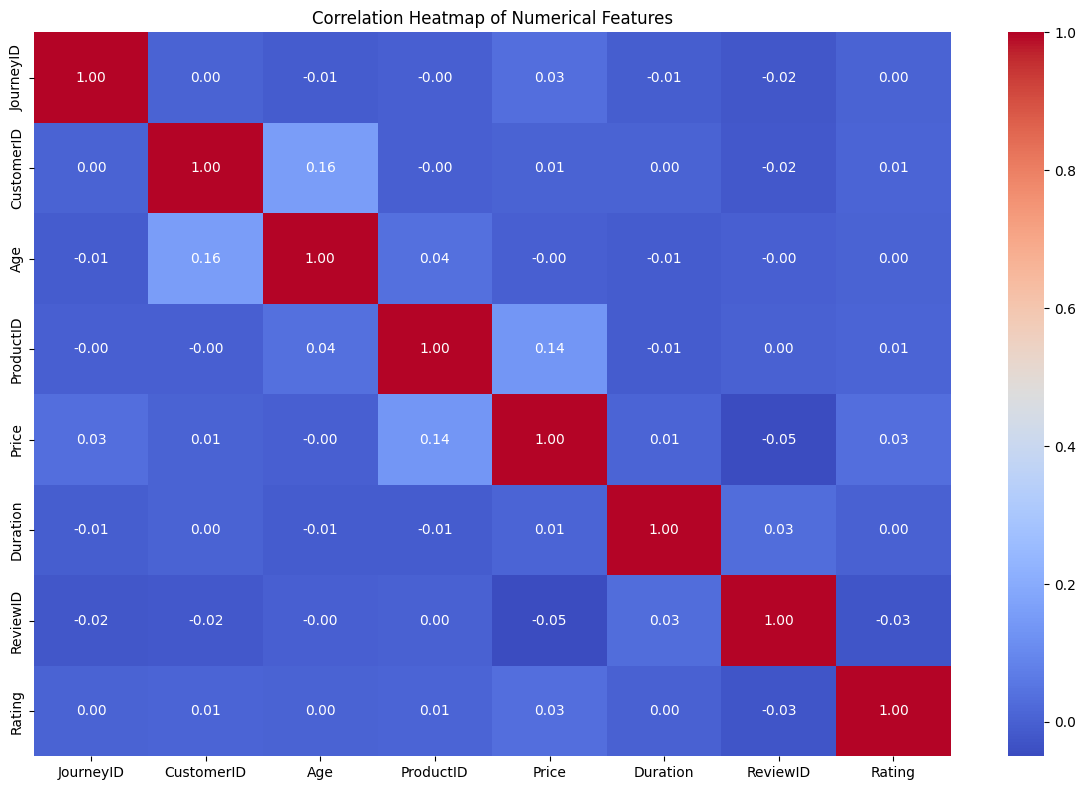

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.select_dtypes('number').corr(),
    annot=True, cmap='coolwarm', fmt='.2f'
)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

### 4.2 Categorical Distributions

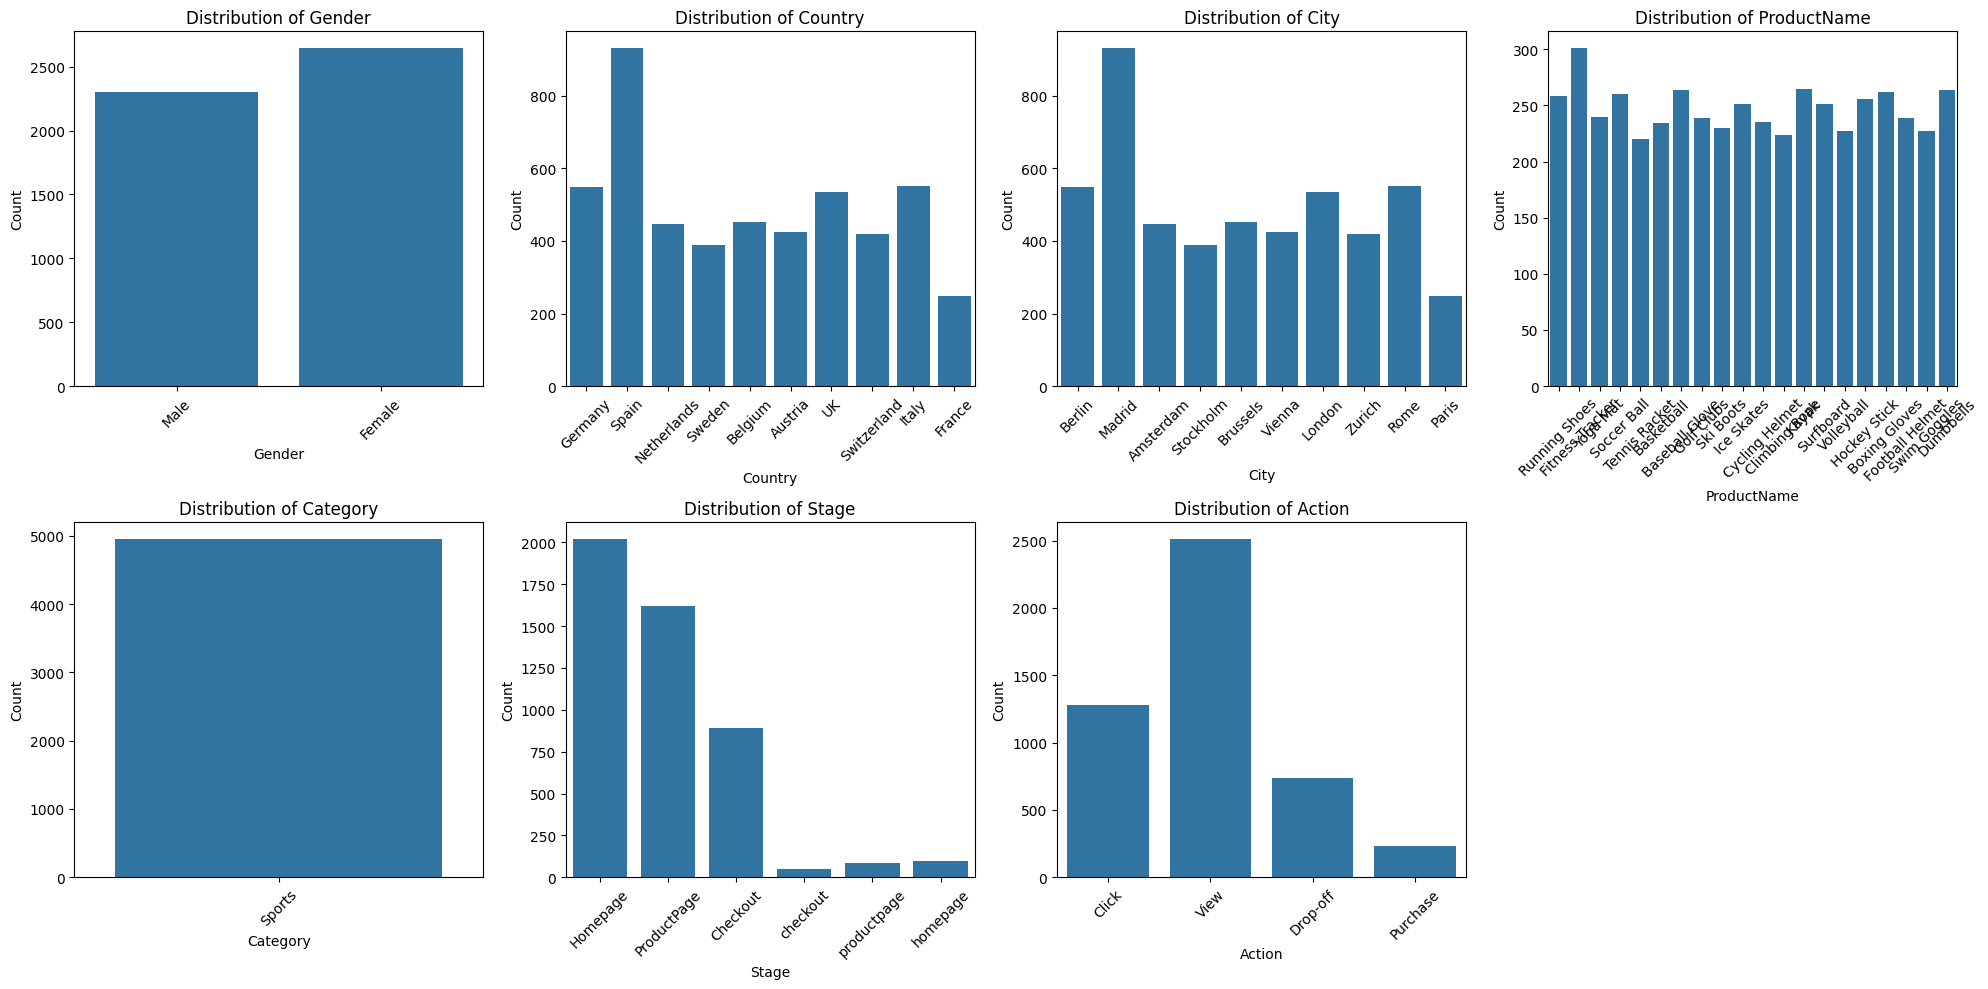

In [ ]:
categorical_data = ['Gender', 'Country', 'City',
                    'ProductName', 'Category', 'Stage', 'Action']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_data):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical_data), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 4.3 Numerical Distributions

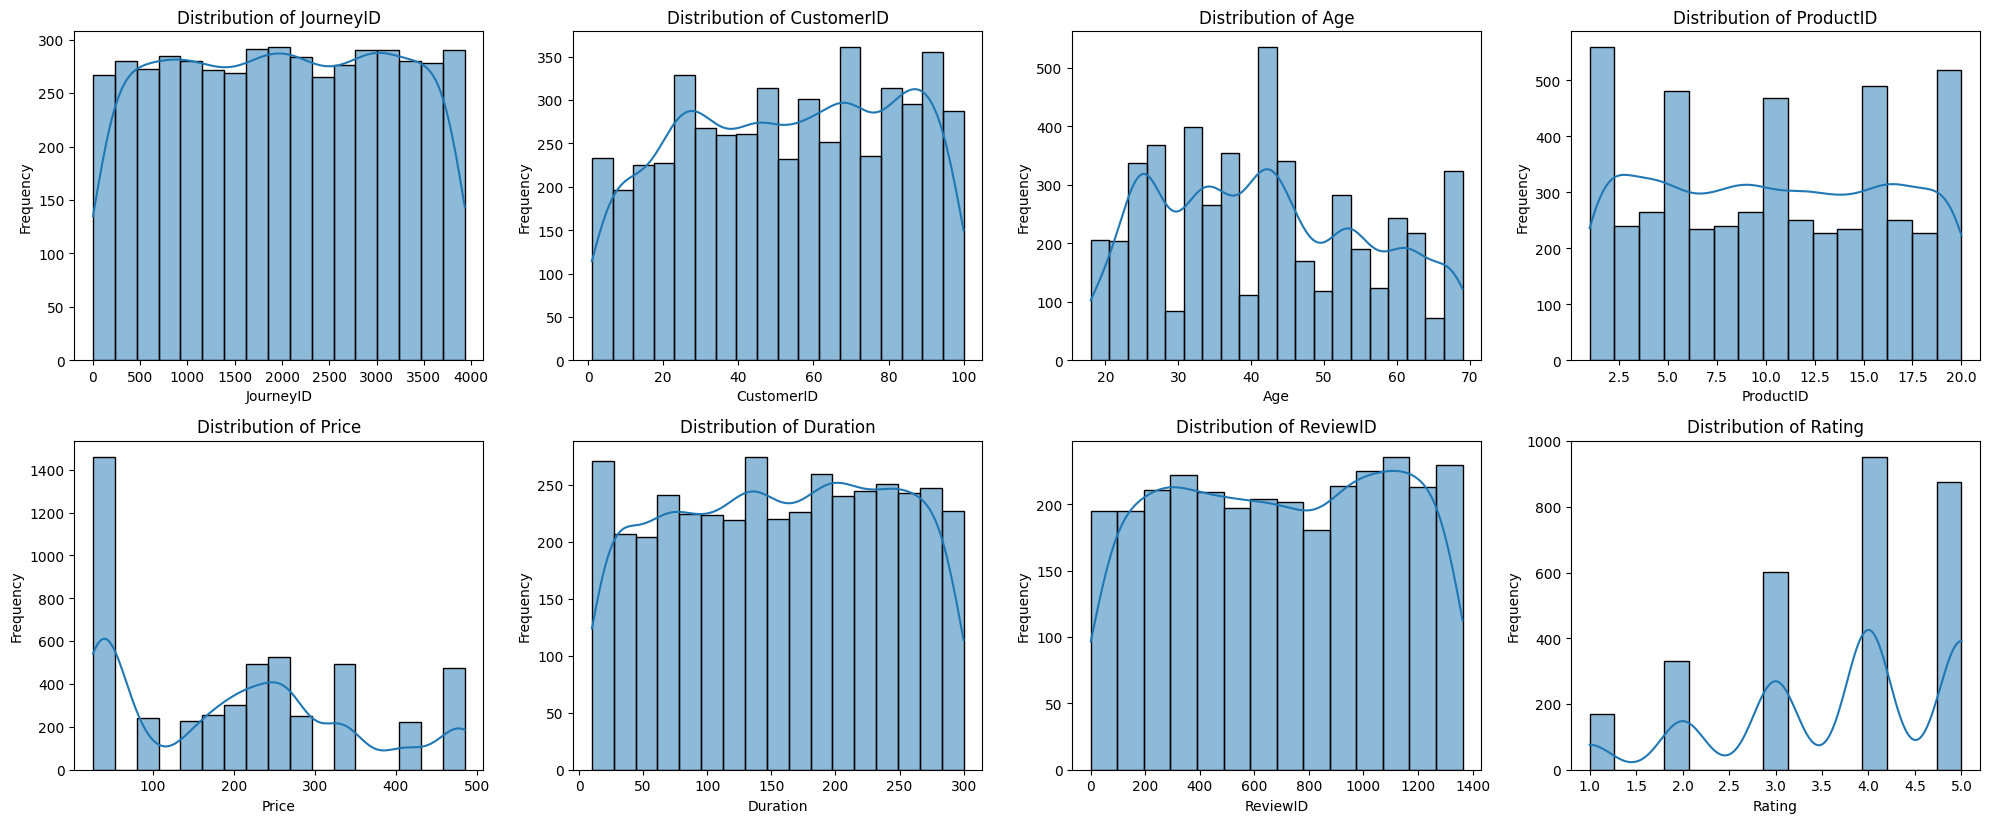

In [ ]:
numerical_cols = df.select_dtypes('number').columns
n_cols = 4
n_rows = (len(numerical_cols) // n_cols) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 4.4 Missing Values

In [ ]:
print('Missing Values per Column:')
missing = df.isna().sum()
print(missing)
print(f'\nTotal missing cells: {df.isna().sum().sum()}')

Missing Values per Column:
JourneyID        184
CustomerID         0
CustomerName       0
Email              0
Gender             0
Age                0
Country            0
City               0
ProductID          0
ProductName        0
Category           0
Price              0
VisitDate        184
Stage            184
Action           184
Duration         922
ReviewID        2013
ReviewDate      2013
Rating          2013
ReviewText      2013
dtype: int64

Total missing cells: 9710


## 5. Feature Engineering

In [ ]:
print("--- Feature Engineering ---")

# Target Variable
df['Converted'] = (df['Action'] == 'Purchase').astype(int)

# Date Features
df['VisitDate']     = pd.to_datetime(df['VisitDate'])
df['Month']         = df['VisitDate'].dt.month
df['DayOfWeek']     = df['VisitDate'].dt.dayofweek
df['Is_Weekend']    = df['DayOfWeek'].isin([5, 6]).astype(int)
df['DayOfWeekName'] = df['VisitDate'].dt.day_name()

# Stage Mapping
stage_map = {'Homepage': 1, 'ProductPage': 2,
             'Cart': 3, 'Checkout': 4, 'Purchase': 5}
df['Stage_Number'] = df['Stage'].map(stage_map)

# Engagement Level
df['Engagement_Level'] = pd.cut(
    df['Duration'],
    bins=[-1, 60, 180, float('inf')],
    labels=['Low', 'Medium', 'High']
)

# Price Bucket
df['Price_Bucket'] = pd.qcut(
    df['Price'], q=3, labels=['Low', 'Medium', 'High']
)

print('New features added:')
print(df[['Month', 'DayOfWeekName', 'Is_Weekend',
          'Stage_Number', 'Engagement_Level',
          'Price_Bucket', 'Converted']].head())

--- Feature Engineering ---
New features added:
   Month DayOfWeekName  Is_Weekend  Stage_Number Engagement_Level  \
0   12.0     Wednesday           0           1.0           Medium   
1    3.0      Saturday           1           1.0              Low   
2    3.0        Monday           0           1.0           Medium   
3    6.0        Friday           0           1.0              Low   
4    3.0        Friday           0           2.0              Low   

  Price_Bucket  Converted  
0       Medium          0  
1       Medium          0  
2       Medium          0  
3       Medium          0  
4       Medium          0  


### 5.1 Conversion Visualizations

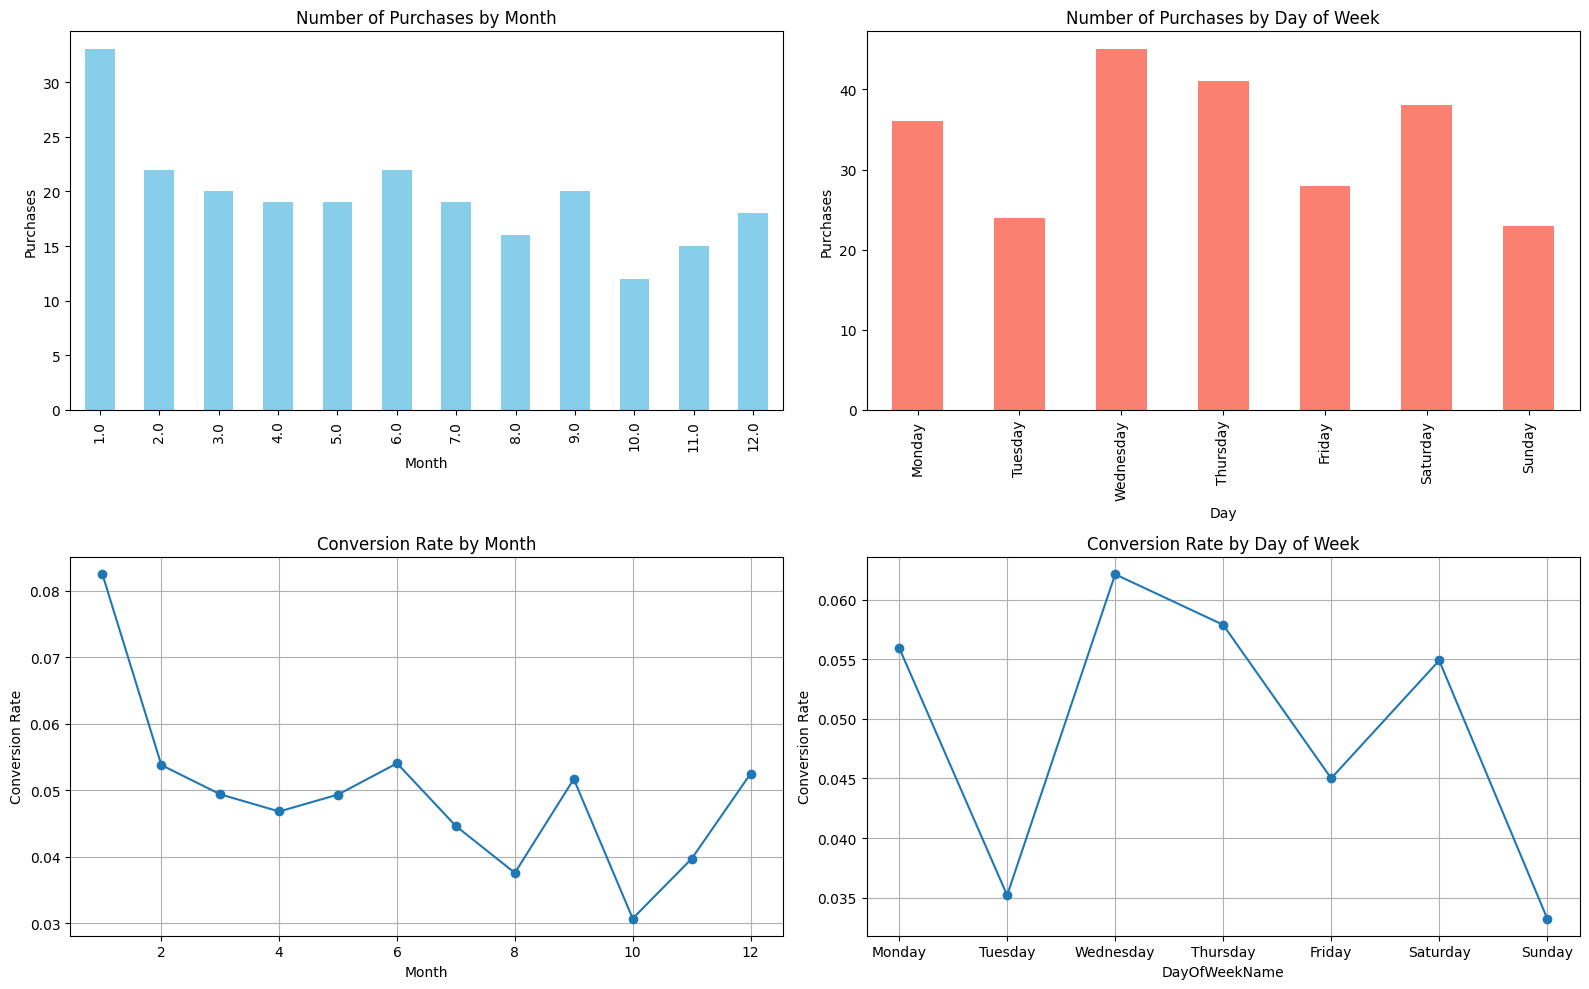

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Purchases by Month
df.groupby('Month')['Converted'].sum().plot(
    kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Number of Purchases by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Purchases')

# Purchases by Day of Week
df.groupby('DayOfWeekName')['Converted'].sum() \
  .reindex(day_order).plot(
    kind='bar', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Number of Purchases by Day of Week')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Purchases')

# Conversion Rate by Month
df.groupby('Month')['Converted'].mean().plot(
    kind='line', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Conversion Rate by Month')
axes[1, 0].set_ylabel('Conversion Rate')
axes[1, 0].grid(True)

# Conversion Rate by Day
df.groupby('DayOfWeekName')['Converted'].mean() \
  .reindex(day_order).plot(
    kind='line', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Conversion Rate by Day of Week')
axes[1, 1].set_ylabel('Conversion Rate')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

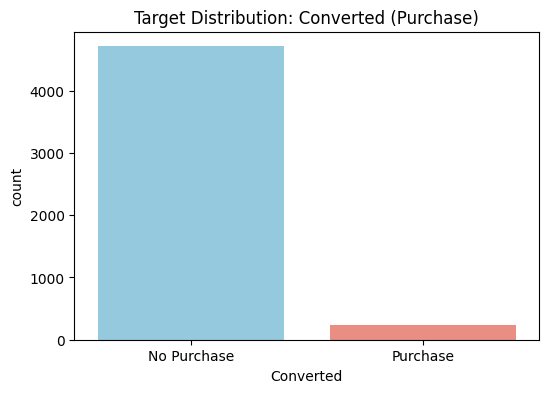

Target Value Counts:
Converted
0    4712
1     235
Name: count, dtype: int64

Conversion Rate: 4.75%


In [ ]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Converted', data=df, palette=['skyblue', 'salmon'])
plt.title('Target Distribution: Converted (Purchase)')
plt.xticks([0, 1], ['No Purchase', 'Purchase'])
plt.show()

print('Target Value Counts:')
print(df['Converted'].value_counts())
print(f'\nConversion Rate: {df["Converted"].mean():.2%}')

## 6. Preprocessing Setup

In [ ]:
print("--- Preprocessing Setup ---")

drop_cols = [
    'JourneyID', 'CustomerID', 'CustomerName', 'Email',
    'ProductID', 'ProductName',
    'VisitDate', 'Action',        # Action = leakage
    'ReviewID', 'ReviewDate', 'Rating', 'ReviewText',
    'Converted',                   # Target
    'DayOfWeek'                    # Redundant with DayOfWeekName
]

X = df.drop(columns=drop_cols)
y = df['Converted']

num_features = ['Age', 'Price', 'Duration',
                'Stage_Number', 'Month', 'Is_Weekend']

cat_features = ['Gender', 'Country', 'City', 'Category',
                'Engagement_Level', 'Price_Bucket', 'DayOfWeekName']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test:  {X_test.shape[0]:,} rows')

preprocessor = ColumnTransformer(transformers=[
    ('num', KNNImputer(n_neighbors=5), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

print('\n✅ Preprocessor ready')

--- Preprocessing Setup ---
Train: 3,957 rows
Test:  990 rows

✅ Preprocessor ready


## 7. Approach 1: Random Forest — Balanced Class Weight

> Handles imbalance by weighting classes inversely proportional to their frequency.

--- Approach 1: Random Forest (Balanced Class Weight) ---
Classification Report (RF Balanced):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       943
           1       0.96      0.49      0.65        47

    accuracy                           0.97       990
   macro avg       0.97      0.74      0.82       990
weighted avg       0.97      0.97      0.97       990



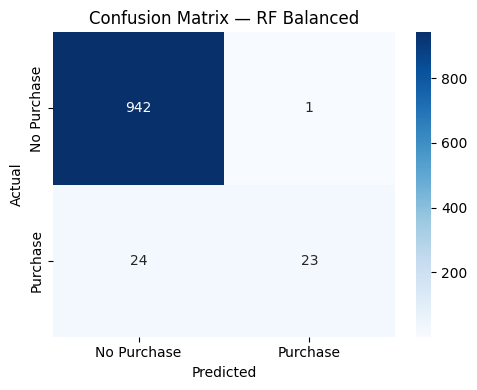

In [ ]:
print("--- Approach 1: Random Forest (Balanced Class Weight) ---")

pipeline_rf = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', RandomForestClassifier(
                 n_estimators=200,
                 class_weight='balanced',
                 random_state=42
             ))
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

print('Classification Report (RF Balanced):')
print(classification_report(y_test, y_pred_rf))

cm1 = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Confusion Matrix — RF Balanced')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Approach 2: Random Forest — SMOTE + Hyperparameter Tuning

> SMOTE generates synthetic minority samples. GridSearchCV finds optimal hyperparameters.

--- Approach 2: SMOTE + GridSearch ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Classification Report (Best SMOTE Model):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       943
           1       0.90      0.79      0.84        47

    accuracy                           0.99       990
   macro avg       0.95      0.89      0.92       990
weighted avg       0.99      0.99      0.99       990



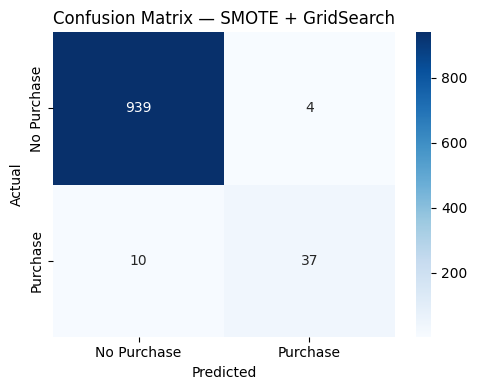

In [ ]:
print("--- Approach 2: SMOTE + GridSearch ---")

pipeline_smote = ImbPipeline(steps=[
    ('preprocess',  preprocessor),
    ('smote',       SMOTE(random_state=42)),
    ('classifier',  RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators':     [100, 200],
    'classifier__max_depth':         [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf':  [1, 2],
    'classifier__class_weight':      ['balanced']
}

grid = GridSearchCV(
    pipeline_smote, param_grid,
    cv=3, scoring='f1', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print(f'\nBest Parameters: {grid.best_params_}')

y_pred_grid = grid.predict(X_test)
print('\nClassification Report (Best SMOTE Model):')
print(classification_report(y_test, y_pred_grid))

cm2 = confusion_matrix(y_test, y_pred_grid)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Confusion Matrix — SMOTE + GridSearch')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### 8.1 Feature Importance (SMOTE Model)

Top 15 Important Features:
                Feature  Importance
           Stage_Number    0.478594
   Engagement_Level_nan    0.091347
          Gender_Female    0.035103
             Is_Weekend    0.035074
            Gender_Male    0.033467
  DayOfWeekName_Tuesday    0.033259
DayOfWeekName_Wednesday    0.030486
   DayOfWeekName_Sunday    0.024879
               Duration    0.019969
            City_Madrid    0.017034
          Country_Spain    0.014646
 DayOfWeekName_Saturday    0.014416
Engagement_Level_Medium    0.013410
                  Month    0.013054
   DayOfWeekName_Monday    0.013035


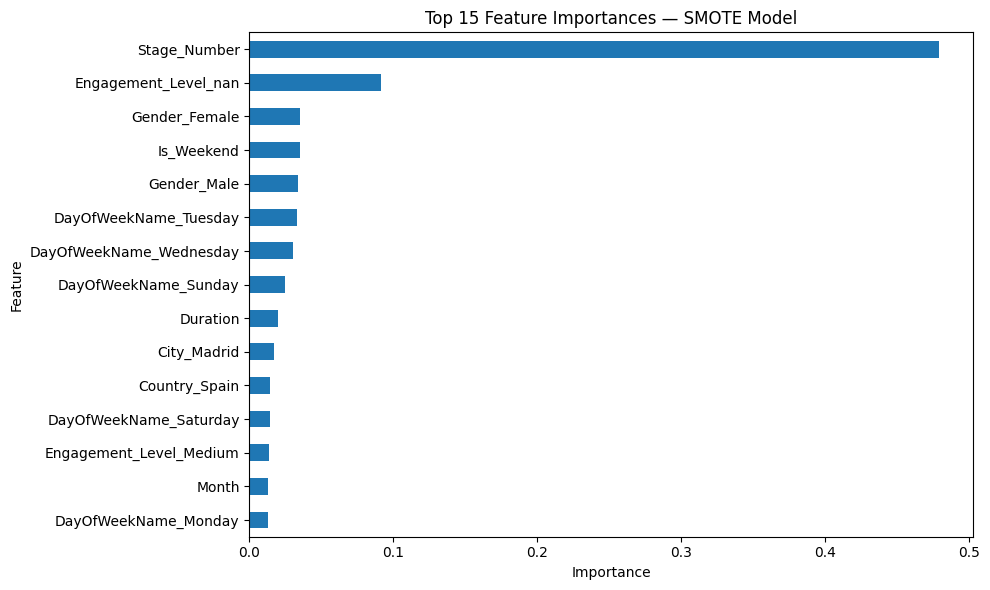

In [ ]:
rf_model  = grid.best_estimator_['classifier']
ohe_feats = (
    grid.best_estimator_['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
all_feats = num_features + list(ohe_feats)

feat_imp_df = pd.DataFrame({
    'Feature':    all_feats,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('Top 15 Important Features:')
print(feat_imp_df.head(15).to_string(index=False))

feat_imp_df.head(15).sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance',
    figsize=(10, 6), legend=False
)
plt.title('Top 15 Feature Importances — SMOTE Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Approach 3: Random Forest — SMOTEENN (Hybrid Sampling)

> Combines SMOTE (over-sampling minority) with Edited Nearest Neighbours (removes noisy majority samples).

--- Approach 3: SMOTEENN ---
Classification Report (SMOTEENN):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       943
           1       0.91      0.64      0.75        47

    accuracy                           0.98       990
   macro avg       0.95      0.82      0.87       990
weighted avg       0.98      0.98      0.98       990



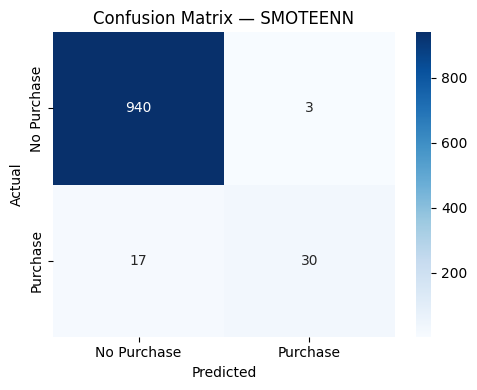

In [ ]:
print("--- Approach 3: SMOTEENN ---")

pipeline_smoteenn = ImbPipeline(steps=[
    ('preprocess',  preprocessor),
    ('smote',       SMOTE(random_state=42)),
    ('enn',         EditedNearestNeighbours()),
    ('classifier',  RandomForestClassifier(random_state=42))
])

pipeline_smoteenn.fit(X_train, y_train)
y_pred_smoteenn = pipeline_smoteenn.predict(X_test)

print('Classification Report (SMOTEENN):')
print(classification_report(y_test, y_pred_smoteenn))

cm3 = confusion_matrix(y_test, y_pred_smoteenn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('Confusion Matrix — SMOTEENN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 10. Results Summary


📊 Model Comparison:
                  Model  Accuracy  Precision  Recall  F1 Score
   RF — Balanced Weight    0.9747     0.9583  0.4894    0.6479
RF — SMOTE + GridSearch    0.9859     0.9024  0.7872    0.8409
          RF — SMOTEENN    0.9798     0.9091  0.6383    0.7500


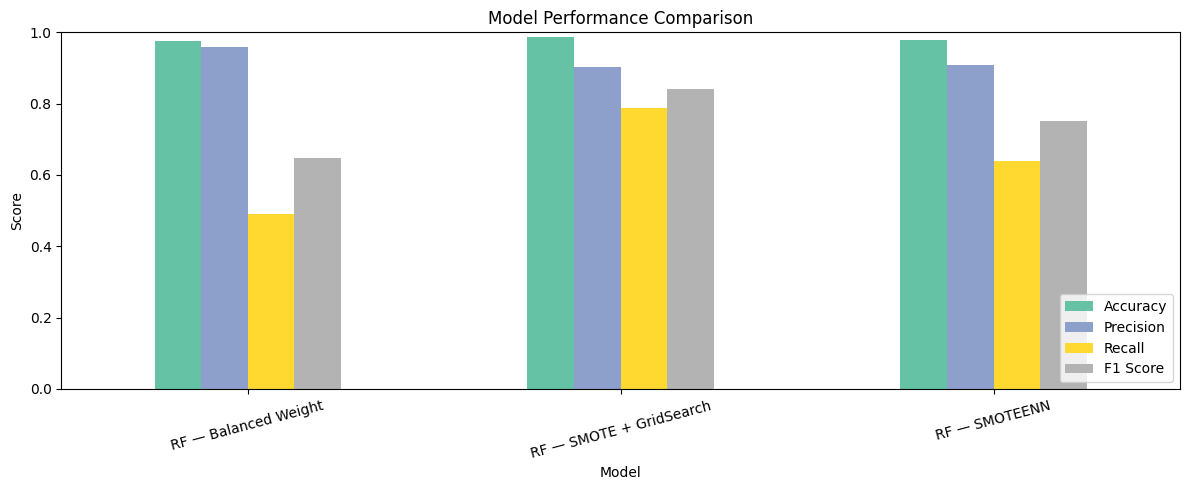


--- Analysis Complete ---


In [ ]:
results = pd.DataFrame({
    'Model': [
        'RF — Balanced Weight',
        'RF — SMOTE + GridSearch',
        'RF — SMOTEENN'
    ],
    'Accuracy':  [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_smoteenn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_grid),
        precision_score(y_test, y_pred_smoteenn)
    ],
    'Recall':    [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_grid),
        recall_score(y_test, y_pred_smoteenn)
    ],
    'F1 Score':  [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_grid),
        f1_score(y_test, y_pred_smoteenn)
    ]
})

print('\n📊 Model Comparison:')
print(results.round(4).to_string(index=False))

results.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2'
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\n--- Analysis Complete ---')